<a href="https://colab.research.google.com/github/thakur698/Data-Science/blob/main/Graphs6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Download latest version
path = kagglehub.dataset_download("yasserh/titanic-dataset")

print("Path to dataset files:", path)
print("Contents of the downloaded directory:", os.listdir(path))

df=pd.read_csv(f"{path}/Titanic-Dataset.csv")
df.head()


Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset
Contents of the downloaded directory: ['Titanic-Dataset.csv']


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [9]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [11]:
df['Age'].describe()

,Age
count,714.000000
mean,29.699118
std,14.526497
min,0.420000
25%,20.125000
50%,28.000000
75%,38.000000
max,80.000000


In [15]:
print(df['Sex'].value_counts())

Sex
male      577
female    314
Name: count, dtype: int64


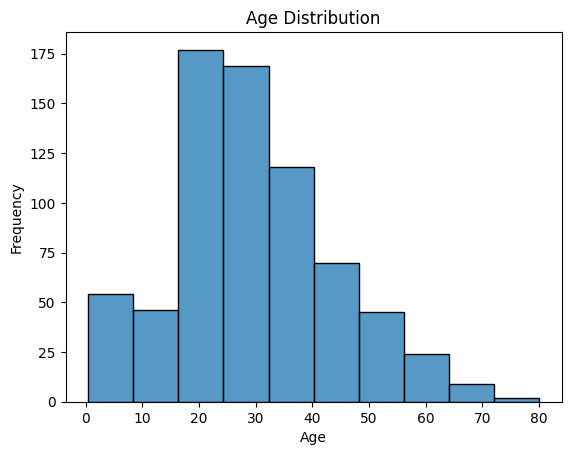

In [20]:
sns.histplot(df['Age'],bins=10)
plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

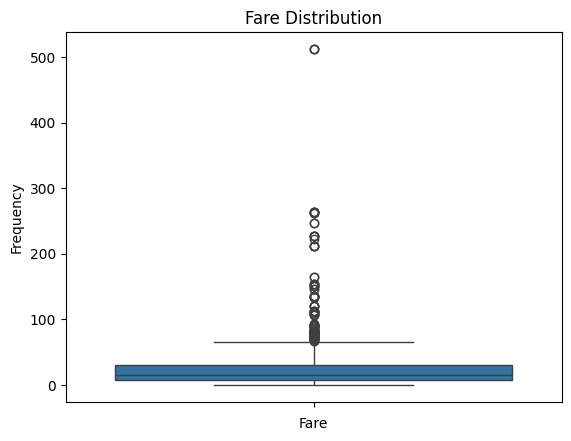

In [27]:
sns.boxplot(data=df['Fare'] )
plt.title('Fare Distribution')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.show()
#comparing Spread and check consistency=box not continuous = dots
#it compares categories like cities gender restauranttypes productcategories
#comparison without dependency

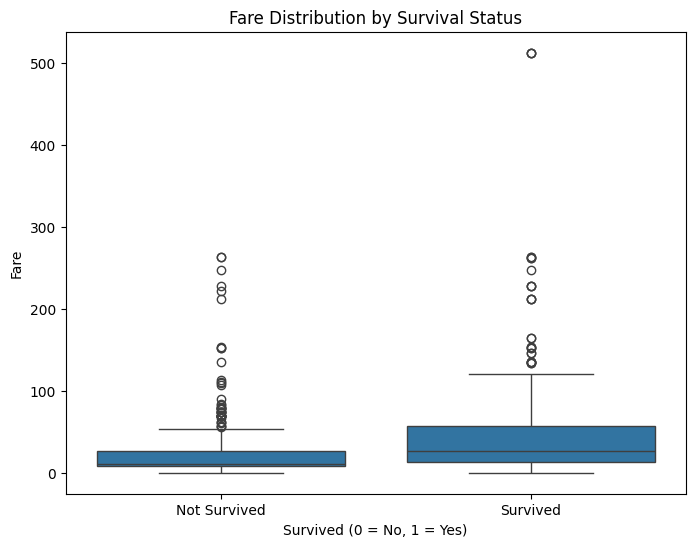

In [26]:
plt.figure(figsize=(8, 6))
sns.boxplot(x='Survived', y='Fare', data=df)
plt.title('Fare Distribution by Survival Status')
plt.xlabel('Survived (0 = No, 1 = Yes)')
plt.ylabel('Fare')
plt.xticks([0, 1], ['Not Survived', 'Survived'])
plt.show()

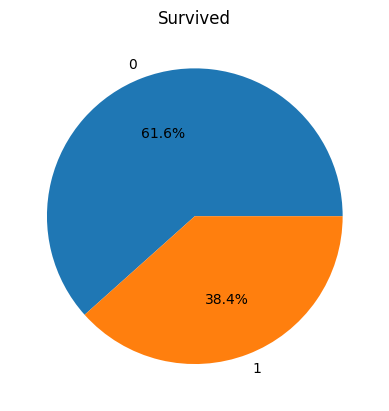

In [30]:
df['Survived'].value_counts().plot(kind='pie',autopct='%1.1f%%')
plt.title('Survived')
plt.ylabel('')
plt.show()
#pie chart used for percentile distribution

BIVARIATE ANALYSIS


first part groupby

In [35]:
print(df.groupby('Sex')['Survived'].value_counts())
#


Sex     Survived
female  1           233
        0            81
male    0           468
        1           109
Name: count, dtype: int64


In [38]:
print(df.groupby('Sex')['Age'].value_counts())

Sex     Age 
female  24.0    16
        18.0    13
        22.0    12
        30.0    11
        35.0     8
                ..
male    57.0     1
        66.0     1
        70.5     1
        74.0     1
        80.0     1
Name: count, Length: 145, dtype: int64


BIVARIATE ANALYSIS (WITH GRAPH)

  
NUMERICAL VS NUMERICAL


Scatter Plot
classification
clustering
corelations

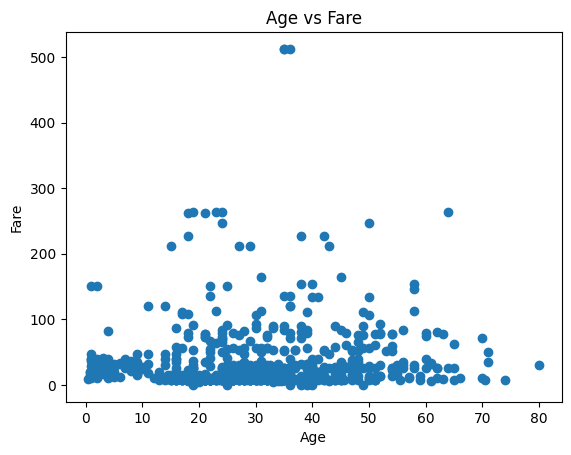

In [39]:
plt.scatter(df['Age'], df['Fare'])
plt.title('Age vs Fare')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()
#

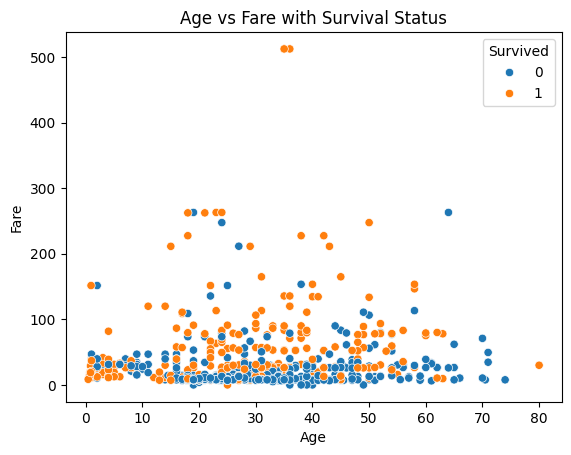

In [40]:
sns.scatterplot(data=df, x='Age', y='Fare', hue='Survived')
plt.title('Age vs Fare with Survival Status')
plt.xlabel('Age')
plt.ylabel('Fare')
plt.show()

BAR GRAPH (CATEGORIAL VS NUMERICAL )

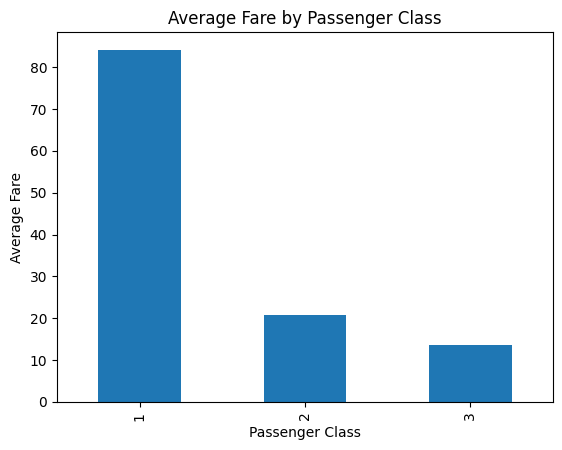

In [47]:
df.groupby('Pclass')['Fare'].mean().plot(kind='bar')
plt.title('Average Fare by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Fare')
plt.show()
#

Multivarient


In [48]:
print(df.groupby(['Sex','Pclass'])['Fare'].mean())

Sex     Pclass
female  1         106.125798
        2          21.970121
        3          16.118810
male    1          67.226127
        2          19.741782
        3          12.661633
Name: Fare, dtype: float64


In [52]:
print(df['Pclass'].value_counts())
#

Pclass
3    491
1    216
2    184
Name: count, dtype: int64


Text(0, 0.5, 'Count')

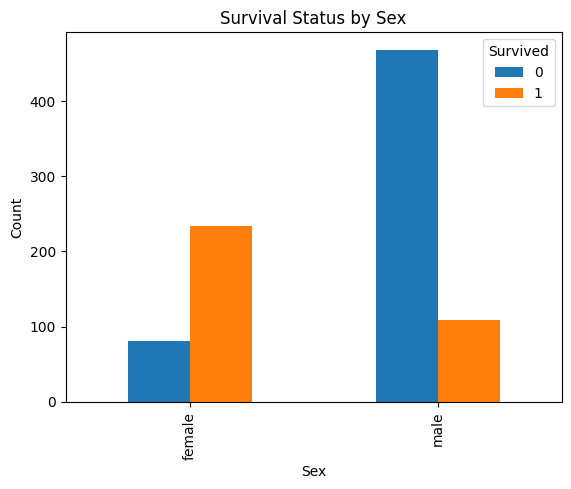

In [54]:
pd.crosstab(df['Sex'],df['Survived']).plot(kind='bar')
plt.title('Survival Status by Sex')
plt.xlabel('Sex')
plt.ylabel('Count')

Line Graph

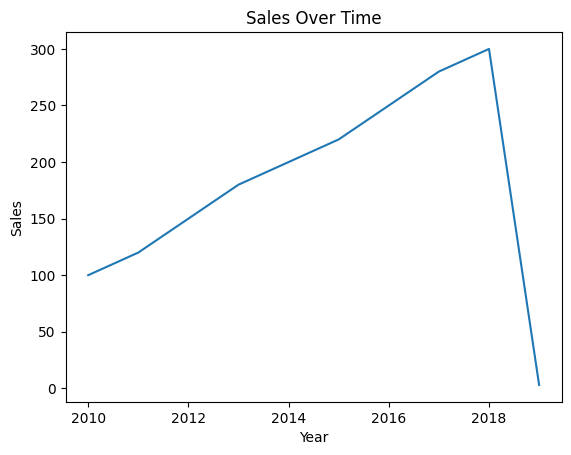

In [55]:
years = [2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019]
sales = [100, 120, 150, 180, 200, 220, 250, 280, 300, 3 ]
plt.plot(years, sales)
plt.title('Sales Over Time')
plt.xlabel('Year')
plt.ylabel('Sales')
plt.show()
#